<center><h1>Numerical nonlinear systems of equation</h1></center>
<center><h3>The Newton method</h3></center>

- - - - - - - - - - - - - - -

In [1]:
import numpy as np
from IPython.display import Image

A machine component to be cut from a sheet of plastic is designed using arcs of ellipses and circles as shown. For given values of $a$, $b$, $c$, $d$, $h$ and $r$, the design is completed by finding the locations of points $O = (z_{1}, z_{2})$, $P = (z_{3}, z_{4})$ and $Q = z_{5}, z_{6}$. These points satisfy the following equations.

$P$ on ellipse: $z_{3}^{2} / a^{2} + z_{4}^{2} / b^{2} = 1$

$Q$ on ellipse: $z_{5}^{2} / c^{2} + (z_{6} + h)^{2} / d^{2} = 1$

$P$ on circle: $(z_{3} - z_{1})^{2} + (z_{4} - z_{2})^{2} = r^{2}$

$Q$ on circle: $(z_{5} - z_{1})^{2} + (z_{6} - z_{2})^{2} = r^{2}$

Ellipse and the cirle have the same slope at $P$: $z_{3}(z_{4} - z_{2})b^{2} = z_{4}(z_{3} - z_{1})a^{2}$

Ellipse and the cirle have the same slope at $Q$: $z_{5}(z_{6} - z_{2})d^{2} = (z_{6} + h)(z_{5} - z_{1})c^{2}$

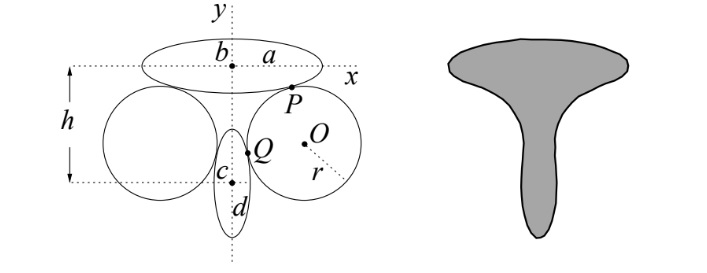

In [2]:
Image('component.jpg')

Here we solve for $O$, $P$ and $Q$ using the <b>Newton method</b>. For concreteness, we assume $a = 3$, $b = 1.5$, $c = 1$, $d = 2$, $h = 3.5$ and $r = 2.5$ (inches).

Write the above equations in the form $F(x) = 0$, where $x = (x_{1}, \dots, x_{6})$, and find an expression for the Jacobian matrix $\frac{\partial F}{\partial x}(x)$. Use the Newton method to solve the equations until $||x^{(k)} - x^{(k - 1)}||_{\infty} < 10^{-6}$. Use the diagram and the values of the constants to make a rough, but reasonable choice of the initial guess $x^{(0)}$. Briefly explain the initial guess used and report the approximate solution and number of iterations required.

In [3]:
def f_eval(a, b, c, d, h, r, x):
    f_0 = (x[2]**2)/(a**2) + (x[3]**2)/(b**2) - 1
    f_1 = (x[4]**2)/(c**2) + ((x[5] + h)**2)/(d**2) - 1
    f_2 = ((x[2] - x[0])**2) + ((x[3] - x[1])**2) - (r**2)
    f_3 = ((x[4] - x[0])**2) + ((x[5] - x[1])**2) - (r**2)
    f_4 = x[2] * (x[3] - x[1]) * (b**2) - x[3] * (x[2] - x[0]) * (a**2)
    f_5 = x[4] * (x[5] - x[1]) * (d**2) - (x[5] + h) * (x[4] - x[0]) * (c**2)
    f = [f_0, f_1, f_2, f_3, f_4, f_5]
    return(f)

def df_eval(a, b, c, d, h, r, x):
    df = np.zeros((6, 6))
    
    df[0][0] = df[0][1] = df[0][4] = df[0][5] = 0
    df[0][2] = (2/(a**2)) * x[2]
    df[0][3] = (2/(b**2)) * x[3]
    
    df[1][0] = df[1][1] = df[1][2] = df[1][3] = 0
    df[1][4] = (2/(c**2)) * x[4]
    df[1][5] = (2/(d**2)) * (x[5] + h)
    
    df[2][0] = -2 * (x[2] - x[0])
    df[2][1] = -2 * (x[3] - x[1])
    df[2][2] = 2 * (x[2] - x[0])
    df[2][3] = 2 * (x[3] - x[1])
    df[2][4] = df[2][5] = 0
    
    df[3][0] = -2 * (x[4] - x[0])
    df[3][1] = -2 * (x[5] - x[1])
    df[3][4] = 2 * (x[4] - x[0])
    df[3][5] = 2 * (x[5] - x[1])
    df[3][2] = df[3][3] = 0
    
    df[4][0] = x[3] * (a**2)
    df[4][1] = -(b**2) * x[2]
    df[4][2] = b**2 * x[3] - b**2 * x[1] - a**2 * x[3]
    df[4][3] = b**2 * x[2] - a**2 * x[2] + a**2 * x[0]
    df[4][4] = df[4][5] = 0
    
    df[5][0] = c**2 * h + c**2 * x[5]
    df[5][1] = -(d**2) * x[4]
    df[5][4] = d**2 * x[5] - d**2 * x[1] - c**2 * x[5] - (c**2 * h)
    df[5][5] = d**2 * x[4] - c**2 * x[4] + c**2 * x[0]
    df[5][2] = df[5][3] = 0
    return(df)

def newton(x, f, df, maxIter, tol):
    iter = 0
    error = 1
    init_x = x
    
    while(iter < maxIter and error >= tol):
        dx = np.linalg.solve(df, f)
        x = x - dx
        error = np.linalg.norm(dx, np.inf)
        f = f_eval(3, 1.5, 1, 2, 3.5, 2.5, x)
        df = df_eval(3, 1.5, 1, 2, 3.5, 2.5, x)
        iter += 1
        
    print(f'Initial guess of x^(0): {init_x}')
    print(f'The solution converged with a |r|_(infinity) = {error}')
    print(f'Iterations needed: {iter}')
    print(f'Approximate solution: {x}')

if __name__ == "__main__":
    x = [3, -3, 2, -1, 1, -3]
    f = f_eval(3, 1.5, 1, 2, 3.5, 2.5, x)
    df = df_eval(3, 1.5, 1, 2, 3.5, 2.5, x)
    newton(x, f, df, 50, 1e-6)

Initial guess of x^(0): [3, -3, 2, -1, 1, -3]
The solution converged with a |r|_(infinity) = 3.056476124003847e-07
Iterations needed: 4
Approximate solution: [ 3.49120976 -3.16228212  2.25421439 -0.98976228  0.99460329 -3.29249773]


Not too bad for an eye test.

## Further readings:
Reading material:<br>
https://www.amazon.com/Numerical-Analysis-Richard-L-Burden/dp/1305253663/

## Useful links:
Quick definition:<br>
https://www.cmu.edu/math/undergrad/suami/pdfs/2014_newton_method.pdf <br>
https://cs357.cs.illinois.edu/textbook/notes/solve_nd.html